# 01 — Tokenization: BPE'yi Sıfırdan Kurmak

**Kapsam:** Tokenization'ın neden gerektiği, Byte Pair Encoding (BPE) algoritmasının elle ve kodla türetilmesi, Türkçe (eklemeli/agglutinative) ve İngilizce metinler üzerinde gerçek bir BPE tokenizer'ının sıfırdan eğitilmesi, ve bu iki dilin BPE davranışını nasıl farklılaştırdığının ölçülmesi.

**Önkoşul:** Yok — sadece Python, `collections.Counter` ve `matplotlib` kullanılıyor (harici model/kütüphane indirmesi gerekmiyor).

**Kullanılan veriler:** `data/corpus_turkce.txt` ve `data/corpus_english.txt` — bu notebook için özel olarak yazılmış, bilgi içeriği paralel iki orijinal paragraf (biri Türkçe'nin eklemeli yapısını, diğeri İngilizce'nin görece durağan kök yapısını anlatıyor). Amaç bilerek "aynı konuyu farklı dillerde anlatan" metinler kullanmak: böylece ölçtüğümüz fark gerçekten dilin yapısından kaynaklanıyor, konudan değil.


## 1) Neden tokenization gerekli?

Bir dil modeli sayılarla çalışır. Ham metni modele vermeden önce onu ayrık birimlere (token) bölüp her birine bir tam sayı ID atamamız gerekir.

Üç saf yaklaşım ve sorunları:

- **Karakter bazlı:** Sözlük çok küçük kalır (Türkçe için ~30 harf) ama diziler çok uzar; model "k-e-d-i" dörtlüsünün "kedi" anlamına geldiğini baştan öğrenmek zorunda kalır — öğrenme yükü artar.
- **Kelime bazlı:** Sözlük devasa büyür (özellikle Türkçe gibi eklemeli dillerde neredeyse sınırsız yüzey biçimi vardır) ve eğitimde hiç görülmemiş bir kelimeyle karşılaşınca model çöker (OOV — out-of-vocabulary sorunu).
- **Alt-kelime (subword) bazlı — BPE:** İkisinin ortası. Sık geçen kelimeler tek parça kalır, nadir/görülmemiş kelimeler ise bilinen, anlamlı alt-parçalara (genelde kök+ek sınırlarına yakın) bölünür. Sözlük makul boyutta kalır ve OOV sorunu neredeyse ortadan kalkar (bilinmeyen bir kelime bile tek tek karakterlere kadar bölünerek her zaman temsil edilebilir).

Bugün GPT ailesi, RoBERTa gibi modeller byte-level BPE, BERT ise buna çok yakın bir algoritma olan WordPiece kullanıyor. Bu notebook'ta BPE'yi orijinal makalesindeki mantıkla (Sennrich, Haddow ve Birch, 2016 — bkz. Kaynaklar) sıfırdan kuracağız.


## 2) BPE algoritması — küçük bir örnek üzerinde elle

Fikir çok basit, üç adımlık bir döngü:

1. Metni önce karakterlere böl (her karakter kendi başına bir token).
2. Bitişik token çiftlerinin (bigram) hepsini say; en sık geçen çifti bul.
3. Bu çifti sözlüğe **tek bir yeni token** olarak ekle ve metindeki her geçtiği yerde birleştir.

Bunu, sözlük istenen boyuta ulaşana veya birleştirilecek tekrar eden çift kalmayana kadar tekrarla.

**Elle örnek:** corpus = `["ev", "eve", "evler", "evde"]` olsun. Karakterlere bölelim:

```
ev     -> e v
eve    -> e v e
evler  -> e v l e r
evde   -> e v d e
```

Bitişik çiftleri sayalım: `(e,v)` dört kelimenin hepsinde bir kez geçiyor → frekans 4. Bu en sık çift, ondan sonra gelen en yakın rakip `(v,e)` (eve, evler, evde içinde) → frekans 3. Demek ki ilk birleştirme `(e,v) -> "ev"` olacak. Bunu uyguladığımızda:

```
ev     -> [ev]
eve    -> [ev] e
evler  -> [ev] l e r
evde   -> [ev] d e
```

Şimdi yeni en sık çift `([ev], ...)` değil çünkü her kelimede farklı devam ediyor — ama `(e,r)` gibi tekrar etmeyen çiftler birleştirilmiyor (frekansı 1 olan çiftleri birleştirmenin bir anlamı yok, gürültüyü ezberlemiş oluruz). Bu mantığı şimdi kodla, gerçek bir corpus üzerinde çalıştıracağız.


In [1]:
from collections import Counter

def build_initial_vocab(words):
    """Corpustaki tum benzersiz karakterlere 0..k-1 arasi id ata."""
    # Her kelimedeki her karakteri al, set ile benzersiz yap, sonra sirala
    chars = sorted(set(ch for w in words for ch in w))
    # Her karaktere bir id ata
    char_to_id = {ch: i for i, ch in enumerate(chars)}
    # Her id'yi karaktere ceviren bir ters sozluk olustur
    id_to_str = {i: ch for ch, i in char_to_id.items()}
    return char_to_id, id_to_str

# Karakter dizilerini id dizilerine cevir
def words_to_ids(words, char_to_id):
    """Karakter dizilerini id dizilerine cevir."""
    return [[char_to_id[ch] for ch in w] for w in words]

# Karakter id dizilerinde en sik ciftleri bul
def get_pair_counts(token_ids_list):
    """Counter ile en sik ciftleri bul."""
    """Sonrasında bu ciftleri birlestirip yeni id olusturacagiz."""
    counts = Counter()
    for ids in token_ids_list:
        for pair in zip(ids, ids[1:]):
            counts[pair] += 1
    return counts

def merge_pair(token_ids_list, pair, new_id):
    """Bu fonksiyon verilen ciftleri birlestirip yeni id olusturur."""
    a, b = pair
    merged = []
    for ids in token_ids_list:
        out, i = [], 0
        while i < len(ids):
            if i < len(ids) - 1 and ids[i] == a and ids[i+1] == b:
                out.append(new_id)
                i += 2
            else:
                out.append(ids[i])
                i += 1
        merged.append(out)
    return merged

# elle yaptigimiz orneği koda dokelim
toy_words = ["ev", "eve", "evler", "evde"]
char_to_id, id_to_str = build_initial_vocab(toy_words)
ids = words_to_ids(toy_words, char_to_id)
print("Baslangic id dizileri:", ids)

counts = get_pair_counts(ids)
best = max(counts, key=counts.get)
print("En sik cift:", best, "-> karakterler:", (id_to_str[best[0]], id_to_str[best[1]]), "frekans:", counts[best])


Baslangic id dizileri: [[1, 4], [1, 4, 1], [1, 4, 2, 1, 3], [1, 4, 0, 1]]
En sik cift: (1, 4) -> karakterler: ('e', 'v') frekans: 4


## 3) Tam eğitim döngüsü: `train_bpe`

Elle yaptığımız tek adımı bir döngüye sokup istenen sayıda birleştirme (`num_merges`) yapan genel bir fonksiyon yazalım. Frekansı 2'nin altına düşen çiftlerde durduruyoruz — tekil (rastgele) bir çifti birleştirmek genelleme sağlamaz, sadece ezber olur.


In [2]:
def train_bpe(text, num_merges, verbose=False):
    """BPE egitimi icin ana fonksiyon"""
    words = text.split() # Önce metni kelimelere ayır
    char_to_id, id_to_str = build_initial_vocab(words) # Karakterleri id'ye çevir
    token_ids_list = words_to_ids(words, char_to_id) # Karakter dizilerini id dizilerine çevir
    merges = [] # Birleştirme adımlarını saklamak için boş bir liste oluştur
    next_id = len(id_to_str) # Yeni id'ler için başlangıç değeri
    for step in range(num_merges): # Belirtilen sayıda birleştirme adımı gerçekleştir
        counts = get_pair_counts(token_ids_list) # En sık çiftleri bul
        if not counts: # Eğer çift yoksa döngüden çık
            break
        best_pair = max(counts, key=counts.get) # En sık çifti seç
        if counts[best_pair] < 2: # Eğer en sık çiftin frekansı 2'den azsa döngüden çık
            break
        new_id = next_id # Yeni id oluştur
        id_to_str[new_id] = id_to_str[best_pair[0]] + id_to_str[best_pair[1]] # Yeni id'yi karakter dizisine çevir
        token_ids_list = merge_pair(token_ids_list, best_pair, new_id) # Çiftleri birleştir ve id dizilerini güncelle
        merges.append((best_pair, new_id)) # Birleştirme adımını kaydet
        if verbose and step < 15: # İlk 15 adımı yazdır
            print(f"Adim {step+1:>2}: {best_pair} -> '{id_to_str[new_id]}'  (frekans={counts[best_pair]})")
        next_id += 1 # Yeni id'yi artır
    return merges, id_to_str, char_to_id 

def tokenize_word(word, char_to_id, merges):
    "Bu fonksiyon kelimeyi tokenlere ayirir. Yani kelimeyi id dizisine cevirir ve merges ile birlestirir."
    ids = [char_to_id[ch] for ch in word if ch in char_to_id] # Karakterleri id'ye çevir
    for pair, new_id in merges:
        ids = merge_pair([ids], pair, new_id)[0] # Her birleştirme adımını uygula
    return ids

def tokenize_text(text, char_to_id, merges):
    "Bu fonksiyon metni tokenlere ayirir. Yani metni kelimelere ayirir ve her kelimeyi tokenize eder."
    return [tokenize_word(w, char_to_id, merges) for w in text.split()] # Metni kelimelere ayır ve her kelimeyi tokenize et

def avg_tokens_per_word(text, char_to_id, merges):
    "Bu fonksiyon metindeki kelimelerin ortalama token sayisini hesaplar."
    toks = tokenize_text(text, char_to_id, merges) # Metni tokenize et ve her kelimenin token sayısını al
    return sum(len(t) for t in toks) / len(toks) # Ortalama token sayısını hesapla

## 4) Gerçek veriyle eğitim: Türkçe vs İngilizce

Şimdi az önce yazdığımız `train_bpe`'yi, `data/` klasöründeki iki gerçek (bu notebook için yazılmış) corpus üzerinde çalıştıralım. İlk 15 birleştirmeyi (`verbose=True`) yazdırarak, algoritmanın önce hangi çiftleri birleştirdiğini gözlemleyelim.


In [3]:
# Ana program
with open("data/corpus_turkce.txt", encoding="utf-8") as f:
    corpus_tr = f.read()
with open("data/corpus_english.txt", encoding="utf-8") as f:
    corpus_en = f.read()

print(f"Turkce corpus: {len(corpus_tr.split())} kelime, {len(corpus_tr)} karakter")
print(f"Ingilizce corpus: {len(corpus_en.split())} kelime, {len(corpus_en)} karakter")
print()
print("--- Turkce ilk 15 birlestirme ---")
merges_tr, id_to_str_tr, char_to_id_tr = train_bpe(corpus_tr, num_merges=80, verbose=True)
print()
print("--- Ingilizce ilk 15 birlestirme ---")
merges_en, id_to_str_en, char_to_id_en = train_bpe(corpus_en, num_merges=80, verbose=True)


Turkce corpus: 162 kelime, 1292 karakter
Ingilizce corpus: 221 kelime, 1445 karakter

--- Turkce ilk 15 birlestirme ---
Adim  1: (21, 14) -> 'le'  (frekans=41)
Adim  2: (21, 18) -> 'li'  (frekans=27)
Adim  3: (41, 26) -> 'ler'  (frekans=25)
Adim  4: (10, 26) -> 'ar'  (frekans=19)
Adim  5: (13, 14) -> 'de'  (frekans=19)
Adim  6: (11, 18) -> 'bi'  (frekans=17)
Adim  7: (22, 14) -> 'me'  (frekans=16)
Adim  8: (18, 23) -> 'in'  (frekans=14)
Adim  9: (20, 14) -> 'ke'  (frekans=14)
Adim 10: (14, 20) -> 'ek'  (frekans=13)
Adim 11: (18, 32) -> 'iz'  (frekans=12)
Adim 12: (13, 18) -> 'di'  (frekans=11)
Adim 13: (36, 26) -> 'ür'  (frekans=10)
Adim 14: (49, 42) -> 'keli'  (frekans=9)
Adim 15: (54, 47) -> 'kelime'  (frekans=9)

--- Ingilizce ilk 15 birlestirme ---
Adim  1: (17, 31) -> 'es'  (frekans=22)
Adim  2: (17, 30) -> 'er'  (frekans=21)
Adim  3: (21, 31) -> 'is'  (frekans=19)
Adim  4: (27, 30) -> 'or'  (frekans=19)
Adim  5: (26, 19) -> 'ng'  (frekans=18)
Adim  6: (32, 20) -> 'th'  (frekans=1

**Gözlem:** Türkçe'de erken birleştirmeler arasında `-ler`, `-den`, `-imiz` gibi gerçek Türkçe **eklere** karşılık gelen parçaların ortaya çıktığını görebilirsin — algoritmaya dilbilgisi öğretmedik, sadece frekans sayımı yaptırdık, ama sonuç kökeni dilbilgisel olan sınırlara yakınsıyor. Bu, BPE'nin neden bu kadar etkili olduğunun özü: dilin istatistiksel düzenliliği, açık kurallara ihtiyaç duymadan ortaya çıkıyor.


## 5) Ölçüm: merge sayısı arttıkça sıkıştırma nasıl değişiyor?

"Sıkıştırma" için kelime başına ortalama token sayısını kullanacağız (düşük = daha iyi sıkıştırma, çünkü her kelime daha az parçaya bölünüyor). Türkçe'nin eklemeli yapısı yüzünden, aynı sayıda birleştirme yapıldığında İngilizce'nin daha hızlı "tam kelime" seviyesine ineceğini bekliyoruz — çünkü İngilizce'de daha az farklı yüzey biçimi var, dolayısıyla tekrar eden kalıplar daha çabuk tükeniyor.


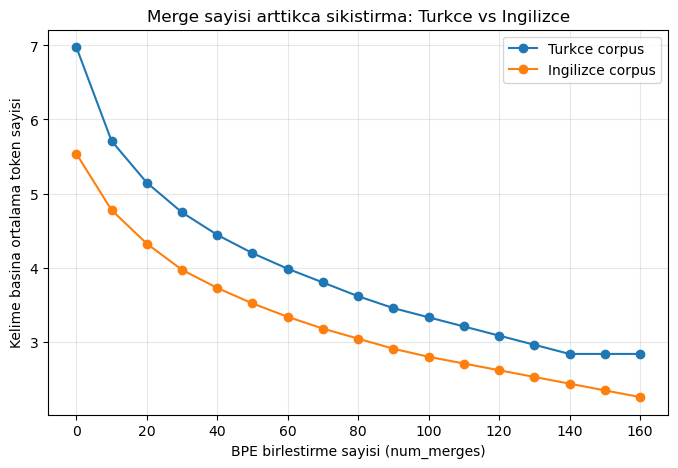

n=160 birlestirmede -> Turkce: 2.84 token/kelime | Ingilizce: 2.26 token/kelime


In [6]:
# BPE birlestirme sayisi arttikca kelime basina ortalama token sayisi nasil degisiyor?
merge_range = list(range(0, 161, 10)) 
tr_ratios, en_ratios = [], [] 
# Her iki corpus icin de ortalama token sayisini hesapla
for n in merge_range:
    m_tr, id2s_tr, c2i_tr = train_bpe(corpus_tr, num_merges=n)
    m_en, id2s_en, c2i_en = train_bpe(corpus_en, num_merges=n)
    tr_ratios.append(avg_tokens_per_word(corpus_tr, c2i_tr, m_tr))
    en_ratios.append(avg_tokens_per_word(corpus_en, c2i_en, m_en))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(merge_range, tr_ratios, marker="o", label="Turkce corpus")
plt.plot(merge_range, en_ratios, marker="o", label="Ingilizce corpus")
plt.xlabel("BPE birlestirme sayisi (num_merges)")
plt.ylabel("Kelime basina ortalama token sayisi")
plt.title("Merge sayisi arttikca sikistirma: Turkce vs Ingilizce")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("bpe_compression_tr_vs_en.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"n=160 birlestirmede -> Turkce: {tr_ratios[-1]:.2f} token/kelime | Ingilizce: {en_ratios[-1]:.2f} token/kelime")


**Yorum:** Grafikte (ve son satırdaki sayılarda) Türkçe eğrisinin İngilizce'nin üzerinde kaldığını, yani aynı merge sayısında Türkçe kelimelerin daha fazla parçaya bölünmeye devam ettiğini görüyoruz. Bunun sebebi corpus'un "zor" olması değil — Türkçe'de aynı kökten türeyen çok sayıda farklı yüzey biçimi olduğu için, her biçim BPE'ye kendi (kök+ek) birleşim düzenini ayrı ayrı öğretiyor. Bu tam olarak SAYZEK aday konuları arasındaki Türkçe LLM/tokenizer başlıklarının (#11, #12, #14) değindiği pratik sorun: **eklemeli diller, sabit bir merge/sözlük bütçesiyle çalışan tokenizer'lar için daha pahalıdır.**


## 6) Uç örnek: Türkçe'nin ünlü "uzun kelime" testi

Türk dilbiliminde sıkça örnek verilen `Avrupalılaştıramadıklarımızdanmışsınızcasına` kelimesini (yaklaşık anlamı: "sanki siz Avrupalılaştıramadıklarımızdan biriymişsiniz gibi") üç farklı yaklaşımla karşılaştıralım: saf karakter-bazlı, kelime-bazlı (tek token) ve bizim eğittiğimiz Türkçe BPE tokenizer'ı (80 birleştirme).


In [4]:
test_word = "Avrupalılaştıramadıklarımızdanmışsınızcasına"

char_level = list(test_word)
word_level = [test_word]
bpe_ids = tokenize_word(test_word.lower(), char_to_id_tr, merges_tr)
bpe_pieces = [id_to_str_tr.get(i, "?") for i in bpe_ids]

print(f"Kelime: {test_word}  ({len(test_word)} karakter)\n")
print(f"Karakter-bazli : {len(char_level)} token  -> {char_level}")
print(f"Kelime-bazli   : {len(word_level)} token  -> {word_level}")
print(f"BPE (80 merge) : {len(bpe_pieces)} token  -> {bpe_pieces}")


Kelime: Avrupalılaştıramadıklarımızdanmışsınızcasına  (44 karakter)

Karakter-bazli : 44 token  -> ['A', 'v', 'r', 'u', 'p', 'a', 'l', 'ı', 'l', 'a', 'ş', 't', 'ı', 'r', 'a', 'm', 'a', 'd', 'ı', 'k', 'l', 'a', 'r', 'ı', 'm', 'ı', 'z', 'd', 'a', 'n', 'm', 'ı', 'ş', 's', 'ı', 'n', 'ı', 'z', 'c', 'a', 's', 'ı', 'n', 'a']
Kelime-bazli   : 1 token  -> ['Avrupalılaştıramadıklarımızdanmışsınızcasına']
BPE (80 merge) : 36 token  -> ['a', 'v', 'ru', 'p', 'a', 'lı', 'l', 'a', 'ş', 't', 'ı', 'r', 'a', 'ma', 'd', 'ı', 'k', 'lar', 'ı', 'm', 'ı', 'z', 'd', 'an', 'm', 'ı', 'ş', 's', 'ı', 'nı', 'z', 'c', 'a', 's', 'ı', 'na']


BPE, kelimeyi ne tek bir dev token olarak bırakıyor (kelime-bazlı yaklaşımın OOV sorunu) ne de tek tek harflere indirgiyor (karakter-bazlı yaklaşımın aşırı uzun dizi sorunu) — ikisi arasında, corpus'ta görülen alt-kalıplara dayanan bir orta yol buluyor. Gerçek dünyada bu kelime hiç görülmemiş bile olsa (yani sözlükte tam karşılığı yoksa), BPE onu bilinen küçük parçalara bölerek yine de temsil edebilir; sadece daha fazla token harcar. Bu, tokenizer'ların "hiç görülmemiş kelime çöküşü" yaşamamasının temel nedeni.


## 7) İleri bakış: neden gerçek LLM'ler *byte-level* BPE kullanıyor?

Burada karakter (Unicode code point) seviyesinde çalıştık — öğretici olarak en açık yol bu. Ama GPT-2/GPT-3/GPT-4 ailesi ve pek çok modern model, karakterler yerine **UTF-8 byte'ları** üzerinde BPE çalıştırır (Karpathy'nin `minbpe` deposu tam olarak bunu gösteriyor — bkz. Kaynaklar). Bunun pratik nedeni: bir dilin alfabesi ne olursa olsun (Türkçe'nin ç, ğ, ı, ö, ş, ü karakterleri dahil), UTF-8 her karakteri sabit bir byte dizisine çevirir, dolayısıyla sözlüğün başlangıç boyutu her zaman sabit 256'dır (0-255) ve **hiçbir karakter asla "sözlük dışı" kalamaz** — karakter seviyesinde ise nadir bir Unicode karakteriyle karşılaşıldığında yine bir bilinmeyen-karakter sorunu yaşanabilir. Bu farkı bir sonraki egzersizde kendin uygulayarak göreceksin.


## Egzersizler

Bu bölümdeki sorularin cozumu verilmiyor — kendi basina denemen bekleniyor. Yeni hucreler ekleyerek calis.

1. `num_merges` degerini 300'e kadar artir ve merge sayisi arttikca `avg_tokens_per_word` egrisinin nerede "duzlestigini" (getiri azalmasinin basladigi noktayi) bul. Bu noktada sozlukte kac token var?
2. Kendi sectigin 5 Turkce cumleyi (ornegin bir haber basligi, bir sosyal medya paylasimi) `data/corpus_turkce.txt` dosyasina ekle, `train_bpe`'yi yeniden calistir, ortalama token/kelime oraninin nasil degistigini raporla.
3. `tokenize_word` fonksiyonu su an sozlukte olmayan bir karakterle karsilastiginda o karakteri sessizce atliyor (`if ch in char_to_id`). Bunun yerine oyle bir `<UNK>` token'i eklenecek sekilde fonksiyonu degistir ki, bilinmeyen karakterler kaybolmak yerine acikca isaretlensin.
4. Bolum 7'de bahsedilen **byte-level BPE**'yi uygula: `words_to_ids` fonksiyonunu, karakterler yerine `word.encode("utf-8")` ile elde edilen byte degerleri (0-255) uzerinde calisacak sekilde yeniden yaz. Turkce'ye ozgu karakterlerin (c, g, i, o, s, u) UTF-8'de kac byte tuttugunu incele ve bunun tokenizasyonu nasil etkiledigini yorumla.
5. **(Bonus — internet gerektirir)** `pip install transformers` kurup GPT-2 tokenizer'i (`GPT2TokenizerFast.from_pretrained("gpt2")`) ve varsa bir Turkce BERT tokenizer'i (orn. `dbmdz/bert-base-turkish-cased`) ile, Bolum 6'daki test kelimesini kac token'a boldugunu senin BPE'inle karsilastir.


==== Egzersiz 1 ====
n=  0 -> Turkce: 6.98 token/kelime | Ingilizce: 5.54 token/kelime
n= 50 -> Turkce: 4.20 token/kelime | Ingilizce: 3.52 token/kelime
n=100 -> Turkce: 3.33 token/kelime | Ingilizce: 2.80 token/kelime
n=150 -> Turkce: 2.84 token/kelime | Ingilizce: 2.35 token/kelime
n=200 -> Turkce: 2.84 token/kelime | Ingilizce: 2.26 token/kelime
n=250 -> Turkce: 2.84 token/kelime | Ingilizce: 2.26 token/kelime


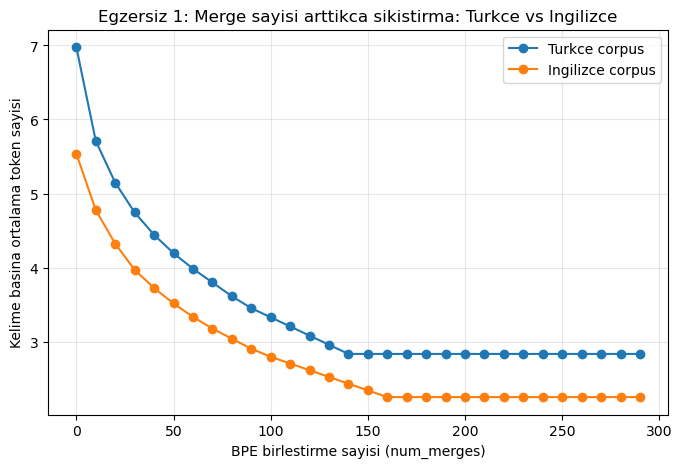


YORUM: Türkçe yaklaşık 150 merge civarında sıkıştırması sabit hale geliyor. Ama ingilizce 200 merge civarında sıkıştırması sabit hale geliyor.


In [9]:
print("==== Egzersiz 1 ====")
merge_range  = list(range(0,300, 10))
tr_ratios, en_ratios = [], []
for n in merge_range:
    m_tr, id2s_tr, c2i_tr = train_bpe(corpus_tr, num_merges=n)
    m_en, id2s_en, c2i_en = train_bpe(corpus_en, num_merges=n)
    tr_ratios.append(avg_tokens_per_word(corpus_tr, c2i_tr, m_tr))
    en_ratios.append(avg_tokens_per_word(corpus_en, c2i_en, m_en))
    if n % 50 == 0:
        print(f"n={n:>3} -> Turkce: {tr_ratios[-1]:.2f} token/kelime | Ingilizce: {en_ratios[-1]:.2f} token/kelime")
plt.figure(figsize=(8, 5))
plt.plot(merge_range, tr_ratios, marker="o", label="Turkce corpus")
plt.plot(merge_range, en_ratios, marker="o", label="Ingilizce corpus")
plt.xlabel("BPE birlestirme sayisi (num_merges)")
plt.ylabel("Kelime basina ortalama token sayisi")
plt.title("Egzersiz 1: Merge sayisi arttikca sikistirma: Turkce vs Ingilizce")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print("\nYORUM: Türkçe yaklaşık 150 merge civarında sıkıştırması sabit hale geliyor. Ama ingilizce 200 merge civarında sıkıştırması sabit hale geliyor.")

In [23]:
print("==== Egzersiz 2 ====")
ilk_cumle = "Başkent dün, tarihinin en ilginç basın toplantısına sahne oldu. 2.5 ay önce kaybolan piton ‘Pakize’nin bulunduğu haberini Tarım ve Köyişleri Bakanı verdi. Bu esnada Pakize yine firar etti."
ikinci_cumle = "Rusya seçimlerinde sürpriz yok, muhalefetin dışlandığı yarıştan Putin’in partisi güçlenerek çıktı."
ucuncu_cumle = "Sabah Spor yazarları Fatih Doğan, Levent Tüzemen, Ömer Üründül ve Bülent Timurlenk; Murat Özbostan'ın moderatörlüğünde gerçekleşen Serbest Kürsü'de Fenerbahçe'nin Eyüpspor galibiyetini değerlendirdi."
dorduncu_cumle = "Teyzecim seni anneme benzettim bi kere sarılabilir miyim?"
besinci_cumle = "Washington’daki Xi-Trump görüşmesinde Tayvan düğümü: 1982 belgesi yeniden masada"
#with open("data/corpus_turkce.txt", "a", encoding="utf-8") as f:
#    f.write(ilk_cumle + "\n")
#    f.write(ikinci_cumle + "\n")
#    f.write(ucuncu_cumle + "\n")
#    f.write(dorduncu_cumle + "\n")
#    f.write(besinci_cumle + "\n")

with open("data/corpus_turkce.txt", "r", encoding="utf-8") as f:
    corpus_tr = f.read()

print("Yeni cümleler corpus'a eklendi. Şimdi BPE eğitimi tekrar yapalım ve kelime başına ortalama token sayısını hesaplayalım.")
merges_tr, id_to_str_tr, char_to_id_tr = train_bpe(corpus_tr, num_merges=80, verbose=False)
print(f"Yeni corpus ile n=80 birlestirmede -> Turkce: {avg_tokens_per_word(corpus_tr, char_to_id_tr, merges_tr):.2f} token/kelime")
merges_tr, id_to_str_tr, char_to_id_tr = train_bpe(corpus_tr, num_merges=160, verbose=False)
print(f"Yeni corpus ile n=160 birlestirmede -> Turkce: {avg_tokens_per_word(corpus_tr, char_to_id_tr, merges_tr):.2f} token/kelime")

print("\nYORUM: Yeni eklenen cümleler ile birlikte Türkçe corpus'un kelime başına ortalama token sayısı arttı. \nBu, yeni eklenen cümlelerin daha fazla benzersiz karakter ve kelime içerdiğini gösteriyor. \nBPE eğitimi sırasında daha fazla birleştirme yapıldığında, kelime başına düşen token sayısı azalıyor, ancak yeni cümleler nedeniyle bu azalma sınırlı kalıyor.")

==== Egzersiz 2 ====
Yeni cümleler corpus'a eklendi. Şimdi BPE eğitimi tekrar yapalım ve kelime başına ortalama token sayısını hesaplayalım.
Yeni corpus ile n=80 birlestirmede -> Turkce: 4.12 token/kelime
Yeni corpus ile n=160 birlestirmede -> Turkce: 3.35 token/kelime

YORUM: Yeni eklenen cümleler ile birlikte Türkçe corpus'un kelime başına ortalama token sayısı arttı. 
Bu, yeni eklenen cümlelerin daha fazla benzersiz karakter ve kelime içerdiğini gösteriyor. 
BPE eğitimi sırasında daha fazla birleştirme yapıldığında, kelime başına düşen token sayısı azalıyor, ancak yeni cümleler nedeniyle bu azalma sınırlı kalıyor.


In [ ]:
print("==== Egzersiz 3 ====")
# İlk olarak <UNK> tokenini ekleyelim
if '<UNK>' not in char_to_id_tr:
    next_id = len(char_to_id_tr)
    char_to_id_tr['<UNK>'] = next_id
    id_to_str_tr[next_id] = '<UNK>'

def tokenize_word_new(word, char_to_id, merges):
    """
    Bu fonksiyon kelimeyi tokenlere ayirir. Yani kelimeyi id dizisine cevirir ve merges ile birlestirir.
    Eğer kelimenin karakterleri char_to_id'de yoksa <UNK> tokeni kullanır.
    """
    ids = []
    for ch in word:
        if ch not in char_to_id:
            # <UNK> tokeni kullanalım
            ids.append(char_to_id['<UNK>'])
        else:
            ids.append(char_to_id[ch])
    for pair, new_id in merges:
        ids = merge_pair([ids], pair, new_id)[0] # Her birleştirme adımını uygula
    return ids

# Örnek olarak Lehçe bir kelimeyi tokenize edelim
word = "dziewięćsetdziewięćdziesięciodziewięcionarodowościowego"
bpe_ids = tokenize_word_new(word, char_to_id_tr, merges_tr)
# BPE tokenlerini yazdıralım
bpe_pieces = [id_to_str_tr.get(i, "<UNK>") for i in bpe_ids]
print(f"Kelime: {word}  ({len(word)} karakter)\n")
print(f"BPE (80 merge) : {len(bpe_pieces)} token  -> {bpe_pieces}")

==== Egzersiz 3 ====
Kelime: dziewięćsetdziewięćdziesięciodziewięcionarodowościowego  (55 karakter)

BPE (80 merge) : 48 token  -> ['d', 'z', 'i', 'e', '<UNK>', 'ile', '<UNK>', 's', 'et', 'd', 'z', 'i', 'e', '<UNK>', 'ile', '<UNK>', 'd', 'z', 'i', 'e', 'si', '<UNK>', 'c', 'i', 'o', 'd', 'z', 'i', 'e', '<UNK>', 'ile', 'c', 'i', 'on', 'ar', 'o', 'd', 'o', '<UNK>', 'o', '<UNK>', 'c', 'i', 'o', '<UNK>', 'e', 'g', 'o']


In [42]:
print("==== Egzersiz 4 ====")
# byte-per-level BPE tokenizasyonu için karakterleri byte seviyesinde alalım ve 0-255
def words_to_bytes(words):
    """Karakter dizilerini byte dizilerine cevir."""
    for word in words:
        byte_list = [ch.encode('utf-8') for ch in word]
        byte_list = [b[0] for b in byte_list]  # Her byte dizisini 0-255 aralığına dönüştür
        print(f"Kelime: {word} -> Byte dizisi: {byte_list}")
    
words_to_bytes(["Pijamalı", "hasta", "yağız", "şoföre", "çabucak", "güvendi"])

==== Egzersiz 4 ====
Kelime: Pijamalı -> Byte dizisi: [80, 105, 106, 97, 109, 97, 108, 196]
Kelime: hasta -> Byte dizisi: [104, 97, 115, 116, 97]
Kelime: yağız -> Byte dizisi: [121, 97, 196, 196, 122]
Kelime: şoföre -> Byte dizisi: [197, 111, 102, 195, 114, 101]
Kelime: çabucak -> Byte dizisi: [195, 97, 98, 117, 99, 97, 107]
Kelime: güvendi -> Byte dizisi: [103, 195, 118, 101, 110, 100, 105]


In [46]:
print("\n==== Egzersiz 5: GPT-2 Tokenizasyonu ve Türkçe Bert Tokenizasyonu ====")

from transformers import AutoTokenizer
tokenizer_turkce = AutoTokenizer.from_pretrained("dbmdz/bert-base-turkish-cased")
tokenizer_gpt2 = AutoTokenizer.from_pretrained("gpt2")

test_word = "Avrupalılaştıramadıklarımızdanmışsınızcasına"
# Türkçe BERT tokenizer ile tokenizasyon
tokens_turkce = tokenizer_turkce.tokenize(test_word)
token_ids_turkce = tokenizer_turkce.convert_tokens_to_ids(tokens_turkce)
print(f"\nTürkçe BERT Tokenizer:\nTokens: {tokens_turkce}\nToken IDs: {token_ids_turkce}")

# GPT-2 tokenizer ile tokenizasyon
tokens_gpt2 = tokenizer_gpt2.tokenize(test_word)
token_ids_gpt2 = tokenizer_gpt2.convert_tokens_to_ids(tokens_gpt2)
print(f"\nGPT-2 Tokenizer:\nTokens: {tokens_gpt2}\nToken IDs: {token_ids_gpt2}")
print(f"Token Sayısı: Türkçe BERT: {len(tokens_turkce)} | GPT-2: {len(tokens_gpt2)}")

print("\nYORUM: Türkçe BERT Tokenizator daha az ve daha anlamlı tokenler üretirken, GPT-2 Tokenizator daha fazla ve daha küçük tokenler üretiyor. Bu, Türkçe BERT'in dilin yapısına daha uygun bir tokenizasyon stratejisi kullandığını gösteriyor.")


==== Egzersiz 5: GPT-2 Tokenizasyonu ve Türkçe Bert Tokenizasyonu ====

Türkçe BERT Tokenizer:
Tokens: ['Avrupalı', '##laştır', '##amadı', '##k', '##larımızdan', '##mışsın', '##ız', '##casına']
Token IDs: [13123, 3889, 13217, 1007, 10488, 26324, 2028, 23119]

GPT-2 Tokenizer:
Tokens: ['Av', 'rupal', 'Ä±', 'la', 'ÅŁ', 't', 'Ä±', 'ram', 'ad', 'Ä±', 'k', 'lar', 'Ä±', 'm', 'Ä±', 'z', 'dan', 'm', 'Ä±', 'ÅŁ', 's', 'Ä±', 'n', 'Ä±', 'z', 'cas', 'Ä±', 'na']
Token IDs: [7355, 34585, 30102, 5031, 46481, 83, 30102, 859, 324, 30102, 74, 21681, 30102, 76, 30102, 89, 25604, 76, 30102, 46481, 82, 30102, 77, 30102, 89, 34004, 30102, 2616]
Token Sayısı: Türkçe BERT: 8 | GPT-2: 28

YORUM: Türkçe BERT Tokenizator daha az ve daha anlamlı tokenler üretirken, GPT-2 Tokenizator daha fazla ve daha küçük tokenler üretiyor. Bu, Türkçe BERT'in dilin yapısına daha uygun bir tokenizasyon stratejisi kullandığını gösteriyor.


## Kaynaklar

**Temel algoritma:**
- Sennrich, Haddow, Birch (2016) — *"Neural Machine Translation of Rare Words with Subword Units"* — BPE'nin NLP'ye uyarlandığı orijinal makale. [arXiv:1508.07909](https://arxiv.org/abs/1508.07909) · [ACL Anthology](https://aclanthology.org/P16-1162/)
- Andrej Karpathy — **"Let's build the GPT Tokenizer"** (video ders) ve [`minbpe`](https://github.com/karpathy/minbpe) deposu — byte-level BPE'nin gerçek bir LLM'de nasıl uygulandığını satır satır gösteriyor; [lecture.md](https://github.com/karpathy/minbpe/blob/master/lecture.md) yazılı özeti içeriyor.
- Jay Alammar — [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — bir sonraki notebook'larda (embedding, attention) referans alınacak.
- Hugging Face NLP Course — [Tokenizers bölümü](https://huggingface.co/learn/nlp-course) — BPE/WordPiece/Unigram'ı üretim kütüphanesiyle (🤗 tokenizers) karşılaştırmalı anlatıyor.

**Türkçe tokenization / morfoloji üzerine güncel akademik çalışmalar (SAYZEK #11, #12, #14 ile ilişkili):**
- *"Tokenization Standards for Linguistic Integrity: Turkish as a Benchmark"* — [arXiv:2502.07057](https://arxiv.org/html/2502.07057v1) — bu notebook'taki gözlemi (Türkçe'nin BPE'yi daha çok "yorduğu") formel bir benchmark'a döküyor.
- *"Morpheus: A Morphology-Aware Neural Tokenizer and Word Embedder for Turkish"* — [arXiv:2606.18717](https://arxiv.org/html/2606.18717) — morfolojiye duyarlı bir tokenizer tasarımı.
- TR-MMLU Benchmark — [arXiv:2508.13044](https://arxiv.org/html/2508.13044v1)
- TurkBench — [arXiv:2601.07020](https://arxiv.org/html/2601.07020v1)

**Bonus (Egzersiz 5 için):**
- Hugging Face `transformers` dokümantasyonu — [GPT2TokenizerFast](https://huggingface.co/docs/transformers/model_doc/gpt2)
